In [1]:
from pathlib import Path
import sys

sys.path.append('..')
from utils import draw_pr_curve_from_cv_results

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [3]:
from aeon.classification.interval_based import (
    TimeSeriesForestClassifier,
    DrCIFClassifier
)
from sklearn.model_selection import cross_validate, StratifiedKFold, GridSearchCV
from aeon.transformations.collection import Normalizer
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyClassifier

In [4]:
sns.set_theme(context='notebook', style='whitegrid', palette='muted')

In [5]:
data_dir = Path('../../results')
train = pd.read_csv(data_dir / 'train_ts.csv', index_col='id')
train['action'] = train['genre'].map(lambda x: 'Action' in x)
train_X = train[[str(i) for i in range(100)]].values.reshape(len(train), 1, 100)

In [6]:
type(train_X), train_X.shape

(numpy.ndarray, (850, 1, 100))

## Rating Category

In [7]:
train_y = train['rating_category']
train_y.shape

(850,)

In [8]:
rating_scores = ('f1_macro', 'accuracy', 'precision_macro', 'recall_macro')

As a baseline we use the performance of a dummy classifier with strategy=stratified on the same folds we use for model selection.

In [9]:
%%capture --no-stdout
# Using cell magic to capture warning on zero division error because I couldn't see the results

dummy = DummyClassifier(strategy='stratified')
baseline = cross_validate(dummy, train_X, train_y, scoring=rating_scores)
for key, value in baseline.items():
    if key.startswith('test'):
        print(f'{key.replace('test_', '')}: {np.mean(value):.2f} ({np.std(value):.2f})')

f1_macro: 0.19 (0.01)
accuracy: 0.28 (0.01)
precision_macro: 0.19 (0.01)
recall_macro: 0.20 (0.01)


### Time Series Forest

In [10]:
tsf = TimeSeriesForestClassifier(random_state=42)

pipeline = Pipeline([
    ('scaler', 'passthrough'),
    ('clf', tsf)
])

In [11]:

param_grid = {
    'clf__min_interval_length': (6, 7, 8, 14, 28, 35),
    'clf__n_estimators': (5, 10, 50, 100, 200),
    'clf__max_interval_length': (.5, 1),
    'scaler': ('passthrough', Normalizer()),
}


grid = GridSearchCV(pipeline,
                    param_grid=param_grid,
                    scoring=('f1_macro'),
                    n_jobs=-1,
                    verbose=2,
                    return_train_score=True)

In [12]:
%%time
grid.fit(train_X, train_y)

Fitting 5 folds for each of 120 candidates, totalling 600 fits
[CV] END clf__max_interval_length=0.5, clf__min_interval_length=6, clf__n_estimators=5, scaler=Normalizer(); total time=   0.8s
[CV] END clf__max_interval_length=0.5, clf__min_interval_length=6, clf__n_estimators=5, scaler=passthrough; total time=   0.9s
[CV] END clf__max_interval_length=0.5, clf__min_interval_length=6, clf__n_estimators=5, scaler=passthrough; total time=   0.9s
[CV] END clf__max_interval_length=0.5, clf__min_interval_length=6, clf__n_estimators=5, scaler=Normalizer(); total time=   0.9s
[CV] END clf__max_interval_length=0.5, clf__min_interval_length=6, clf__n_estimators=5, scaler=Normalizer(); total time=   0.9s
[CV] END clf__max_interval_length=0.5, clf__min_interval_length=6, clf__n_estimators=5, scaler=passthrough; total time=   1.0s
[CV] END clf__max_interval_length=0.5, clf__min_interval_length=6, clf__n_estimators=5, scaler=passthrough; total time=   0.9s
[CV] END clf__max_interval_length=0.5, clf__m

GridSearchCV(estimator=Pipeline(steps=[('scaler', 'passthrough'),
                                       ('clf',
                                        TimeSeriesForestClassifier(random_state=42))]),
             n_jobs=-1,
             param_grid={'clf__max_interval_length': (0.5, 1),
                         'clf__min_interval_length': (6, 7, 8, 14, 28, 35),
                         'clf__n_estimators': (5, 10, 50, 100, 200),
                         'scaler': ('passthrough', Normalizer())},
             return_train_score=True, scoring='f1_macro', verbose=2)

In [13]:
results = pd.DataFrame(grid.cv_results_)

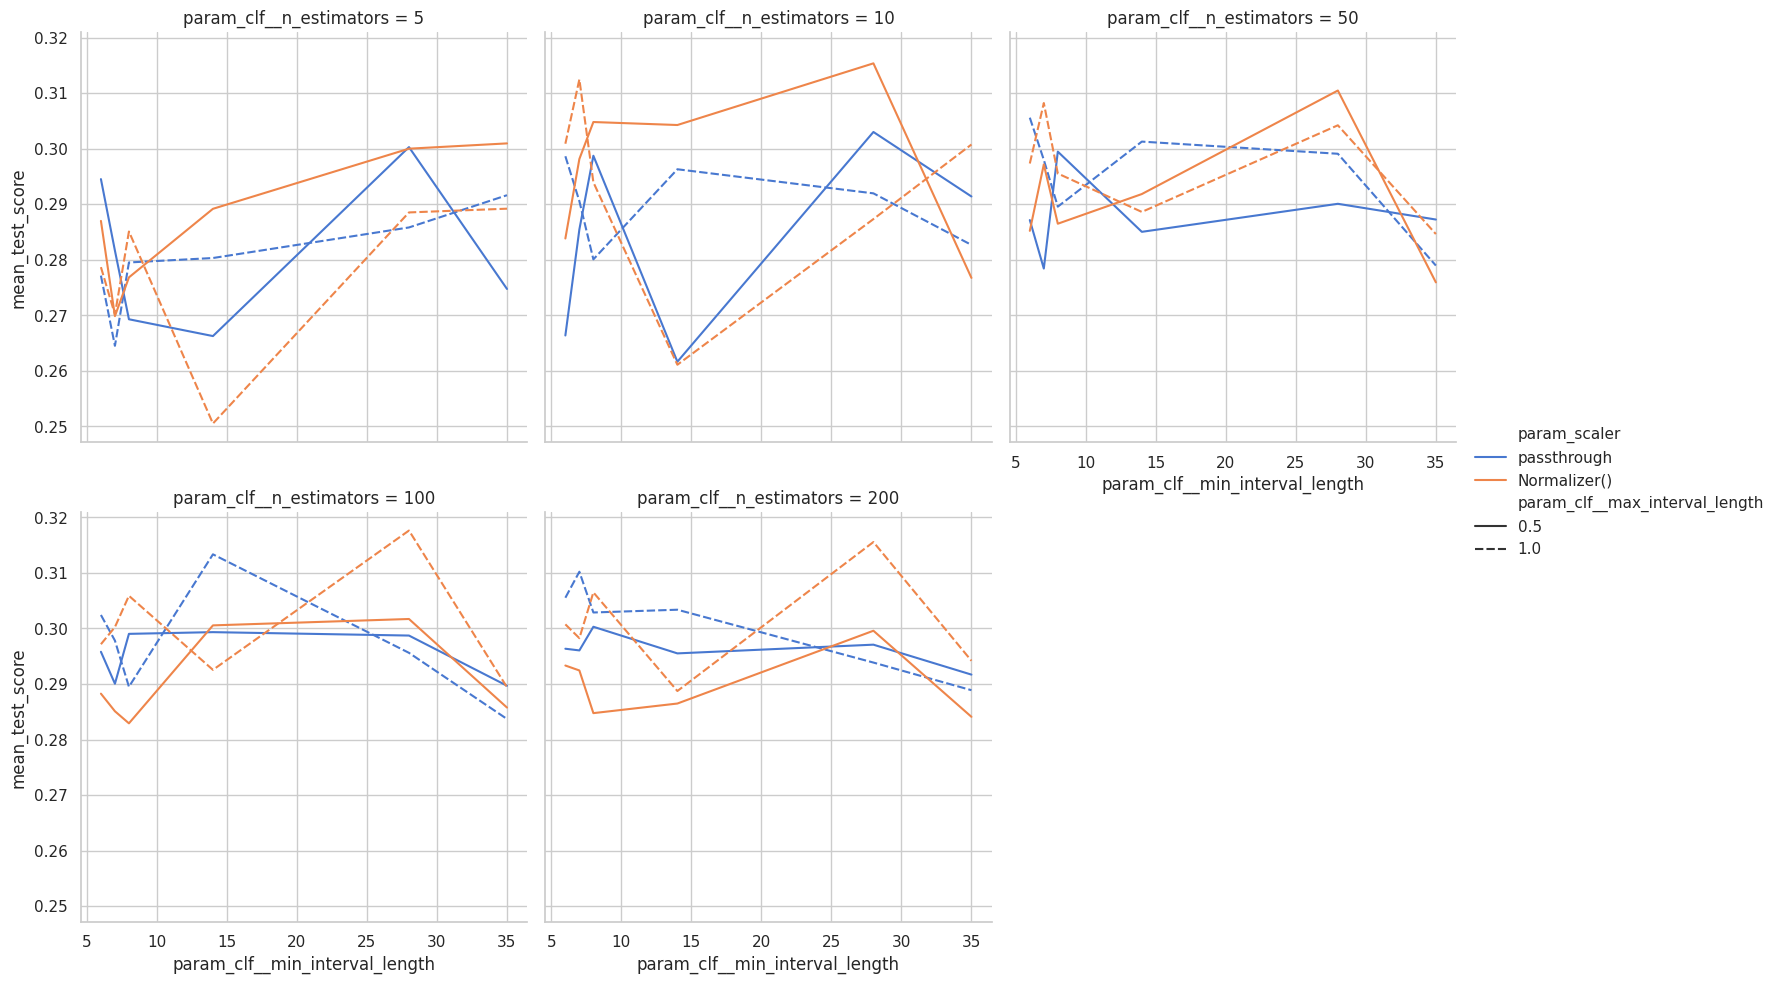

In [14]:
results = pd.DataFrame(grid.cv_results_)
sns.relplot(results, x='param_clf__min_interval_length', y='mean_test_score', kind='line',
            col='param_clf__n_estimators',
            hue='param_scaler',
            style='param_clf__max_interval_length',
            col_wrap=3)

In [15]:
grid.best_params_

{'clf__max_interval_length': 1,
 'clf__min_interval_length': 28,
 'clf__n_estimators': 100,
 'scaler': Normalizer()}

In [16]:
%%capture --no-stdout

tsf_results = cross_validate(grid.best_estimator_, train_X, train_y, scoring=rating_scores, return_train_score=True)
for key, value in tsf_results.items():
    if key.startswith('test'):
        print(f'{key.replace('test_', '')}: {np.mean(value):.2f} ({np.std(value):.2f})')

f1_macro: 0.32 (0.03)
accuracy: 0.45 (0.04)
precision_macro: 0.35 (0.05)
recall_macro: 0.32 (0.03)


In [17]:
print("Results on the training set:")
for key, value in tsf_results.items():
    if key.startswith('train'):
        print(f'{key.replace('train_', '')}: {np.mean(value):.2f} ({np.std(value):.2f})')

Results on the training set:
f1_macro: 1.00 (0.00)
accuracy: 1.00 (0.00)
precision_macro: 1.00 (0.00)
recall_macro: 1.00 (0.00)


### DrCif

In [18]:
drcif = DrCIFClassifier(random_state=42)

drcif_pipeline = Pipeline([
    ('scaler', 'passthrough'),
    ('clf', drcif)
])


dr_cif_param_grid = {
    'clf__min_interval_length': (6, 7, 8, 14, 28, 35),
    'clf__n_estimators': (5, 10),
    'clf__max_interval_length': (.5, 1),
    'scaler': ('passthrough', Normalizer()),
}

grid = GridSearchCV(drcif_pipeline,
                    param_grid=dr_cif_param_grid,
                    scoring=('f1_macro'),
                    n_jobs=-1,
                    verbose=2,
                    return_train_score=True)

In [19]:
%%time
grid.fit(train_X, train_y)

Fitting 5 folds for each of 48 candidates, totalling 240 fits
[CV] END clf__max_interval_length=0.5, clf__min_interval_length=6, clf__n_estimators=5, scaler=Normalizer(); total time=   6.3s
[CV] END clf__max_interval_length=0.5, clf__min_interval_length=6, clf__n_estimators=5, scaler=Normalizer(); total time=   6.7s
[CV] END clf__max_interval_length=0.5, clf__min_interval_length=6, clf__n_estimators=5, scaler=Normalizer(); total time=   6.6s
[CV] END clf__max_interval_length=0.5, clf__min_interval_length=6, clf__n_estimators=5, scaler=passthrough; total time=   6.8s
[CV] END clf__max_interval_length=0.5, clf__min_interval_length=6, clf__n_estimators=5, scaler=passthrough; total time=   6.8s
[CV] END clf__max_interval_length=0.5, clf__min_interval_length=6, clf__n_estimators=5, scaler=passthrough; total time=   7.4s
[CV] END clf__max_interval_length=0.5, clf__min_interval_length=6, clf__n_estimators=5, scaler=passthrough; total time=   7.4s
[CV] END clf__max_interval_length=0.5, clf__mi

GridSearchCV(estimator=Pipeline(steps=[('scaler', 'passthrough'),
                                       ('clf',
                                        DrCIFClassifier(random_state=42))]),
             n_jobs=-1,
             param_grid={'clf__max_interval_length': (0.5, 1),
                         'clf__min_interval_length': (6, 7, 8, 14, 28, 35),
                         'clf__n_estimators': (5, 10),
                         'scaler': ('passthrough', Normalizer())},
             return_train_score=True, scoring='f1_macro', verbose=2)

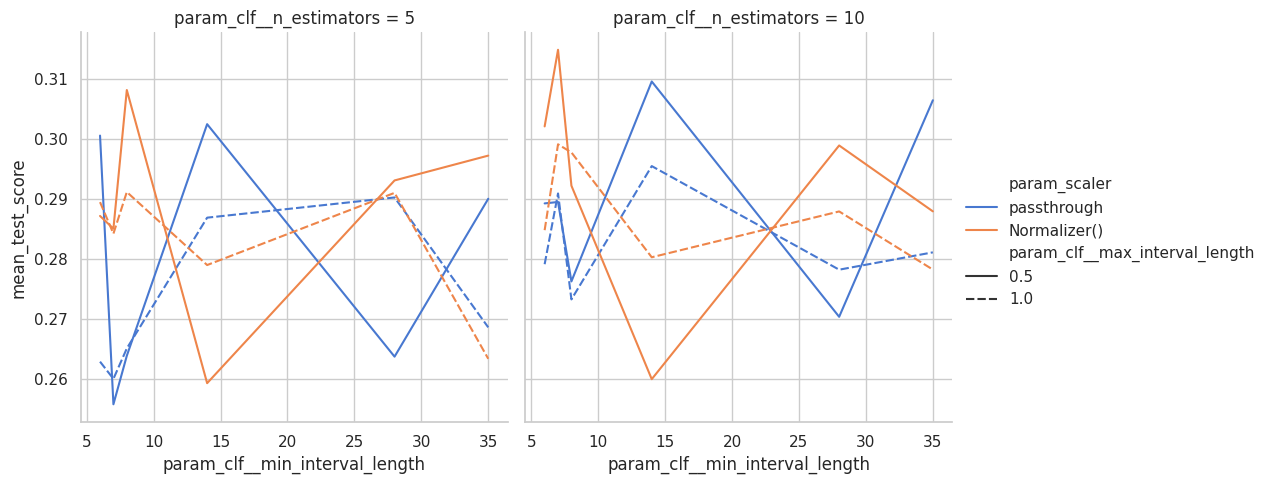

In [20]:
results = pd.DataFrame(grid.cv_results_)
sns.relplot(results, x='param_clf__min_interval_length', y='mean_test_score', kind='line',
            col='param_clf__n_estimators',
            hue='param_scaler',
            style='param_clf__max_interval_length')

In [21]:
grid.best_params_

{'clf__max_interval_length': 0.5,
 'clf__min_interval_length': 7,
 'clf__n_estimators': 10,
 'scaler': Normalizer()}

In [22]:
%%capture --no-stdout

drcif_results = cross_validate(grid.best_estimator_, train_X, train_y, scoring=rating_scores, return_train_score=True)
for key, value in drcif_results.items():
    if key.startswith('test'):
        print(f'{key.replace('test_', '')}: {np.mean(value):.2f} ({np.std(value):.2f})')

f1_macro: 0.31 (0.03)
accuracy: 0.46 (0.05)
precision_macro: 0.35 (0.04)
recall_macro: 0.32 (0.03)


In [23]:
print("Results on the training set:")
for key, value in drcif_results.items():
    if key.startswith('train'):
        print(f'{key.replace('train_', '')}: {np.mean(value):.2f} ({np.std(value):.2f})')

Results on the training set:
f1_macro: 1.00 (0.00)
accuracy: 1.00 (0.00)
precision_macro: 1.00 (0.00)
recall_macro: 1.00 (0.00)


## Action

In [24]:
train_y = train['action']

In [25]:
action_scores = ('f1', 'precision', 'recall', 'accuracy', 'average_precision')

In [26]:
%%capture --no-stdout
# Using cell magic to capture warning on zero division error because I couldn't see the results

dummy = DummyClassifier(strategy='stratified')
baseline = cross_validate(dummy, train_X, train_y, scoring=action_scores)
for key, value in baseline.items():
    if key.startswith('test'):
        print(f'{key.replace('test_', '')}: {np.mean(value):.2f} ({np.std(value):.2f})')

f1: 0.29 (0.02)
precision: 0.30 (0.03)
recall: 0.29 (0.02)
accuracy: 0.55 (0.02)
average_precision: 0.31 (0.00)


### TSF

In [27]:
grid = GridSearchCV(pipeline,
                    param_grid=param_grid,
                    scoring=('f1'),
                    n_jobs=-1,
                    verbose=2,
                    return_train_score=True,)

In [28]:
%%time
grid.fit(train_X, train_y)

Fitting 5 folds for each of 120 candidates, totalling 600 fits
[CV] END clf__max_interval_length=0.5, clf__min_interval_length=6, clf__n_estimators=5, scaler=passthrough; total time=   0.2s
[CV] END clf__max_interval_length=0.5, clf__min_interval_length=6, clf__n_estimators=5, scaler=passthrough; total time=   0.2s
[CV] END clf__max_interval_length=0.5, clf__min_interval_length=6, clf__n_estimators=5, scaler=passthrough; total time=   0.2s
[CV] END clf__max_interval_length=0.5, clf__min_interval_length=6, clf__n_estimators=5, scaler=Normalizer(); total time=   0.3s
[CV] END clf__max_interval_length=0.5, clf__min_interval_length=6, clf__n_estimators=5, scaler=passthrough; total time=   0.3s
[CV] END clf__max_interval_length=0.5, clf__min_interval_length=6, clf__n_estimators=5, scaler=Normalizer(); total time=   0.4s
[CV] END clf__max_interval_length=0.5, clf__min_interval_length=6, clf__n_estimators=5, scaler=passthrough; total time=   0.3s
[CV] END clf__max_interval_length=0.5, clf__mi

GridSearchCV(estimator=Pipeline(steps=[('scaler', 'passthrough'),
                                       ('clf',
                                        TimeSeriesForestClassifier(random_state=42))]),
             n_jobs=-1,
             param_grid={'clf__max_interval_length': (0.5, 1),
                         'clf__min_interval_length': (6, 7, 8, 14, 28, 35),
                         'clf__n_estimators': (5, 10, 50, 100, 200),
                         'scaler': ('passthrough', Normalizer())},
             return_train_score=True, scoring='f1', verbose=2)

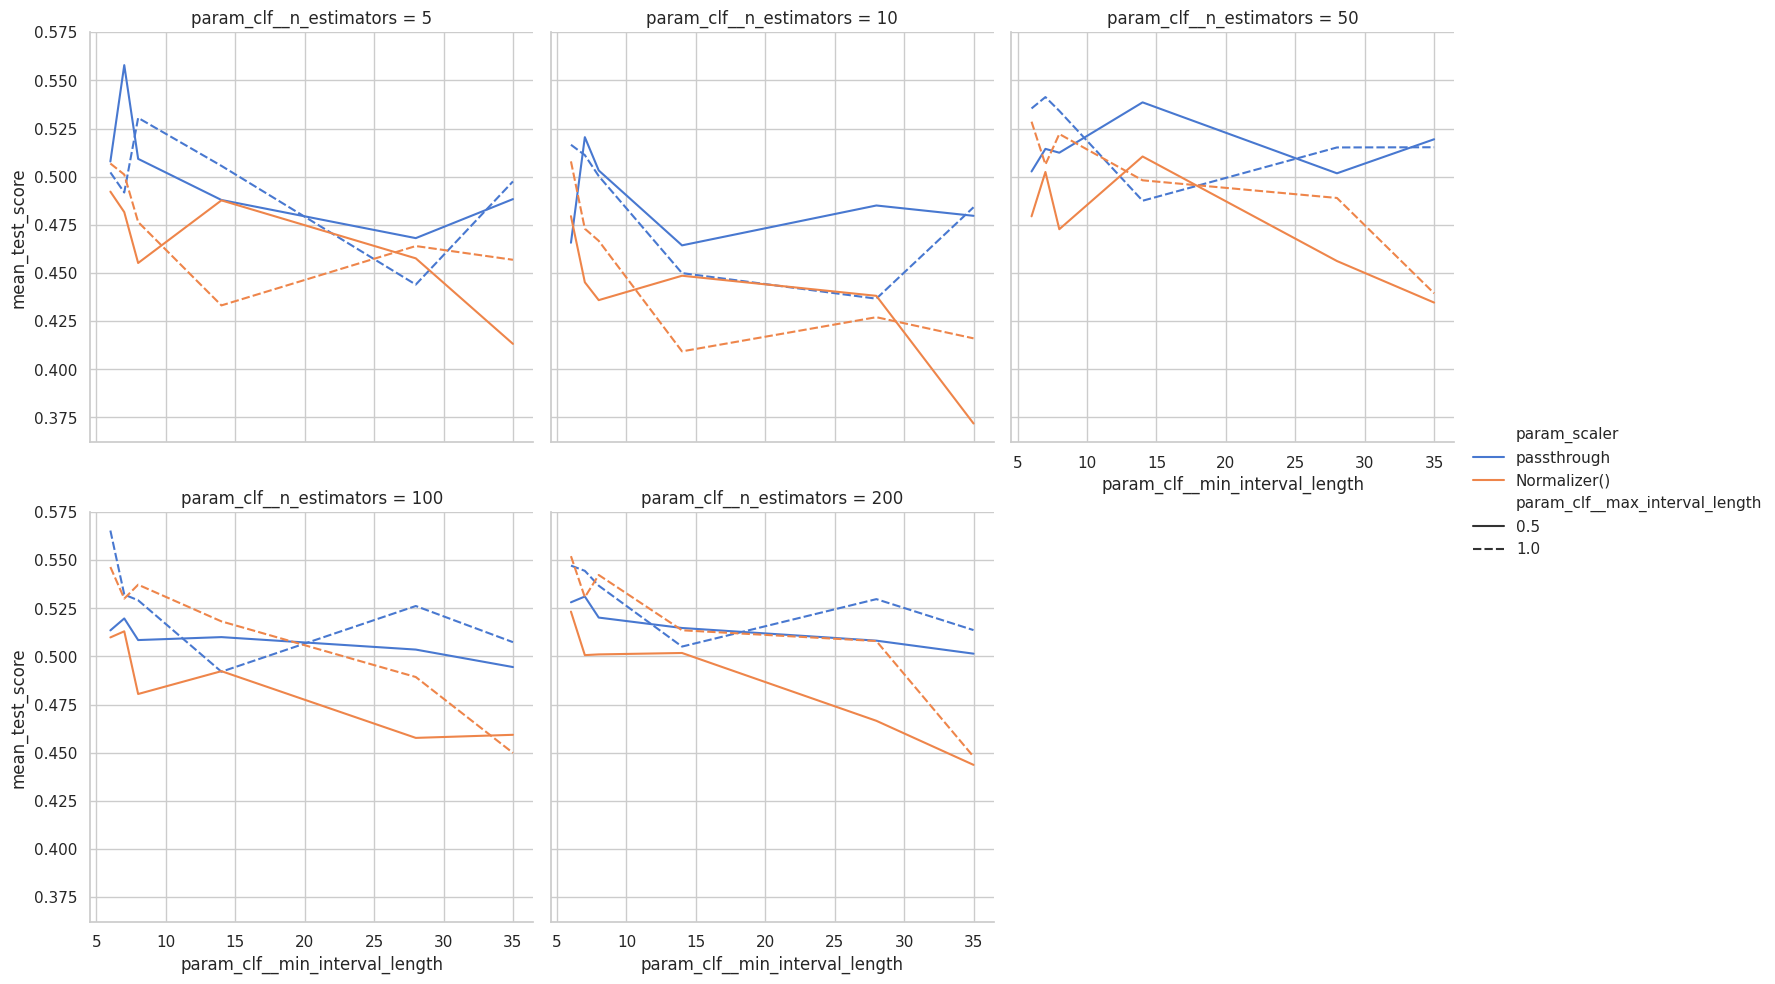

In [29]:
results = pd.DataFrame(grid.cv_results_)
sns.relplot(results, x='param_clf__min_interval_length', y='mean_test_score', kind='line',
            col='param_clf__n_estimators',
            hue='param_scaler',
            style='param_clf__max_interval_length',
            col_wrap=3)

In [30]:
grid.best_params_

{'clf__max_interval_length': 1,
 'clf__min_interval_length': 6,
 'clf__n_estimators': 100,
 'scaler': 'passthrough'}

In [31]:
%%capture --no-stdout

tsf_results_action = cross_validate(grid.best_estimator_, train_X, train_y, scoring=action_scores,
return_train_score=True, return_estimator=True, return_indices=True)
for key, value in tsf_results_action.items():
    if key.startswith('test'):
        print(f'{key.replace('test_', '')}: {np.mean(value):.2f} ({np.std(value):.2f})')

f1: 0.57 (0.03)
precision: 0.70 (0.03)
recall: 0.47 (0.04)
accuracy: 0.77 (0.01)
average_precision: 0.67 (0.03)


In [32]:
print("Results on the training set:")
for key, value in tsf_results_action.items():
    if key.startswith('train'):
        print(f'{key.replace('train_', '')}: {np.mean(value):.2f} ({np.std(value):.2f})')

Results on the training set:
f1: 1.00 (0.00)
precision: 1.00 (0.00)
recall: 1.00 (0.00)
accuracy: 1.00 (0.00)
average_precision: 1.00 (0.00)


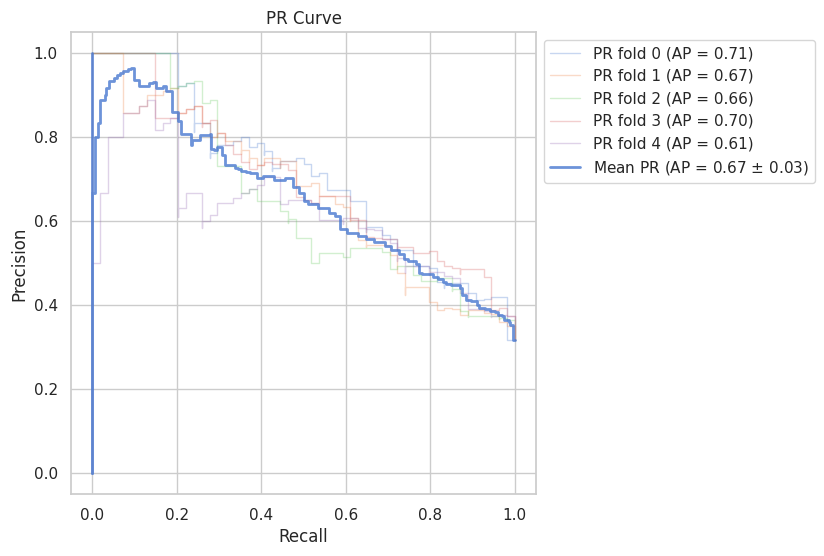

In [33]:
draw_pr_curve_from_cv_results(tsf_results_action, train_X, train_y)

### DrCif

In [34]:
grid = GridSearchCV(drcif_pipeline,
                    param_grid=dr_cif_param_grid,
                    scoring=('f1'),
                    n_jobs=-1,
                    verbose=2,
                    return_train_score=True)

In [35]:
%%time
grid.fit(train_X, train_y)

Fitting 5 folds for each of 48 candidates, totalling 240 fits
[CV] END clf__max_interval_length=0.5, clf__min_interval_length=6, clf__n_estimators=5, scaler=passthrough; total time=   6.1s
[CV] END clf__max_interval_length=0.5, clf__min_interval_length=6, clf__n_estimators=5, scaler=Normalizer(); total time=   6.3s
[CV] END clf__max_interval_length=0.5, clf__min_interval_length=6, clf__n_estimators=5, scaler=passthrough; total time=   6.4s
[CV] END clf__max_interval_length=0.5, clf__min_interval_length=6, clf__n_estimators=5, scaler=passthrough; total time=   6.0s
[CV] END clf__max_interval_length=0.5, clf__min_interval_length=6, clf__n_estimators=5, scaler=Normalizer(); total time=   6.8s
[CV] END clf__max_interval_length=0.5, clf__min_interval_length=6, clf__n_estimators=5, scaler=Normalizer(); total time=   7.1s
[CV] END clf__max_interval_length=0.5, clf__min_interval_length=6, clf__n_estimators=5, scaler=passthrough; total time=   6.7s
[CV] END clf__max_interval_length=0.5, clf__mi

GridSearchCV(estimator=Pipeline(steps=[('scaler', 'passthrough'),
                                       ('clf',
                                        DrCIFClassifier(random_state=42))]),
             n_jobs=-1,
             param_grid={'clf__max_interval_length': (0.5, 1),
                         'clf__min_interval_length': (6, 7, 8, 14, 28, 35),
                         'clf__n_estimators': (5, 10),
                         'scaler': ('passthrough', Normalizer())},
             return_train_score=True, scoring='f1', verbose=2)

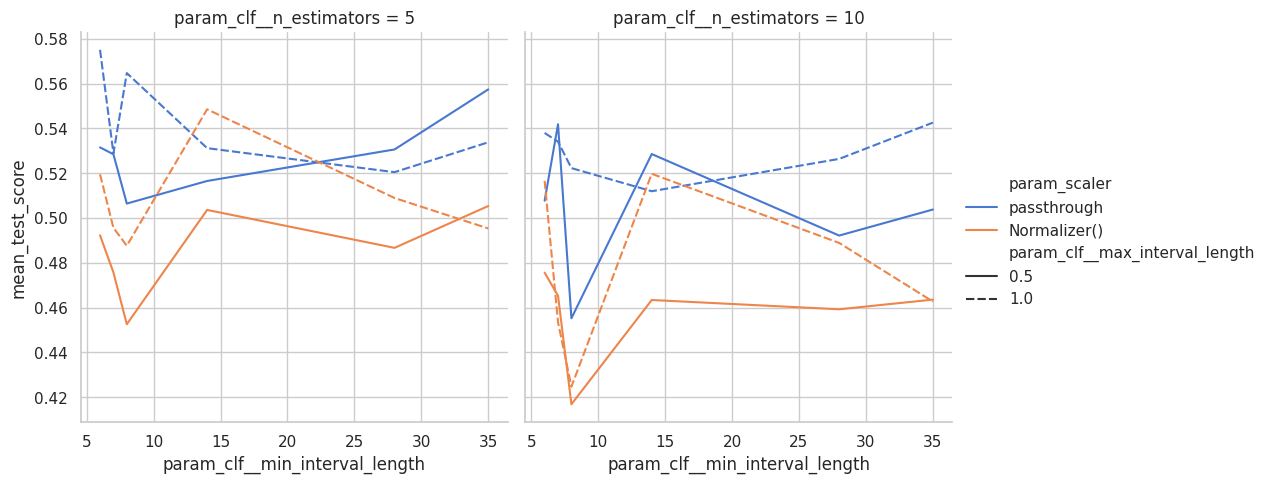

In [36]:
results = pd.DataFrame(grid.cv_results_)
sns.relplot(results, x='param_clf__min_interval_length', y='mean_test_score', kind='line',
            col='param_clf__n_estimators',
            hue='param_scaler',
            style='param_clf__max_interval_length')

In [37]:
grid.best_params_

{'clf__max_interval_length': 1,
 'clf__min_interval_length': 6,
 'clf__n_estimators': 5,
 'scaler': 'passthrough'}

In [38]:
%%capture --no-stdout

drcif_results_action = cross_validate(grid.best_estimator_, train_X, train_y, scoring=action_scores,
return_train_score=True, return_estimator=True, return_indices=True)
for key, value in drcif_results_action.items():
    if key.startswith('test'):
        print(f'{key.replace('test_', '')}: {np.mean(value):.2f} ({np.std(value):.2f})')

f1: 0.58 (0.05)
precision: 0.59 (0.06)
recall: 0.56 (0.04)
accuracy: 0.74 (0.03)
average_precision: 0.57 (0.05)


In [39]:
print("Results on the training set:")
for key, value in drcif_results_action.items():
    if key.startswith('train'):
        print(f'{key.replace('train_', '')}: {np.mean(value):.2f} ({np.std(value):.2f})')

Results on the training set:
f1: 1.00 (0.00)
precision: 1.00 (0.00)
recall: 1.00 (0.00)
accuracy: 1.00 (0.00)
average_precision: 1.00 (0.00)


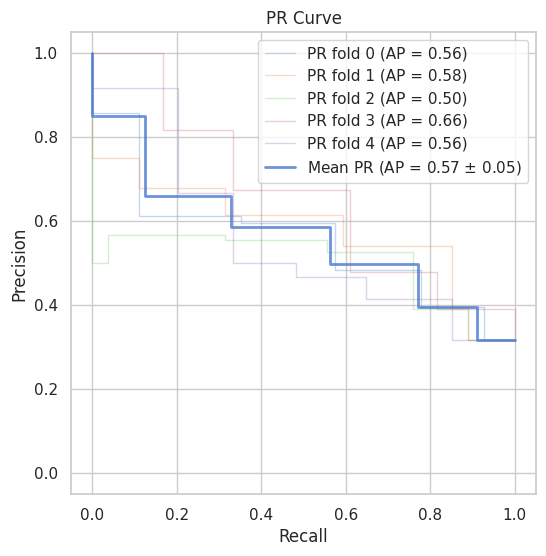

In [40]:
draw_pr_curve_from_cv_results(drcif_results_action, train_X, train_y)